# Model Interpretability

## Objective

The objective of this notebook is to understand how the selected machine learning model makes predictions.

Interpretability techniques include:

- Feature Importance
- SHAP Summary Plot
- SHAP Bar Plot
- SHAP Waterfall Plot
- Local Prediction Explanation

These techniques improve model transparency and support business decision making.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import joblib
import shap

from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data.dataset_manager import DatasetManager

In [24]:
dataset_manager = DatasetManager()

X_train_processed, X_test_processed, y_train, y_test = (
    dataset_manager.load_processed_data()
)

best_model = joblib.load(
    "../artifacts/best_model.pkl"
)

label_encoder = joblib.load(
    "../artifacts/label_encoder.pkl"
)

✅ Processed datasets loaded successfully.


In [4]:
importance = pd.DataFrame({

    "Feature": X_train_processed.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

,Feature,Importance
0,sleep_duration,4329
2,bmi,3300
6,water_intake,1395
1,heart_rate,1167
5,exercise_duration,1109
4,step_count,1036
10,stress_level_high,1019
16,physical_activity_level_active,927
11,stress_level_low,779
3,calorie_expenditure,757


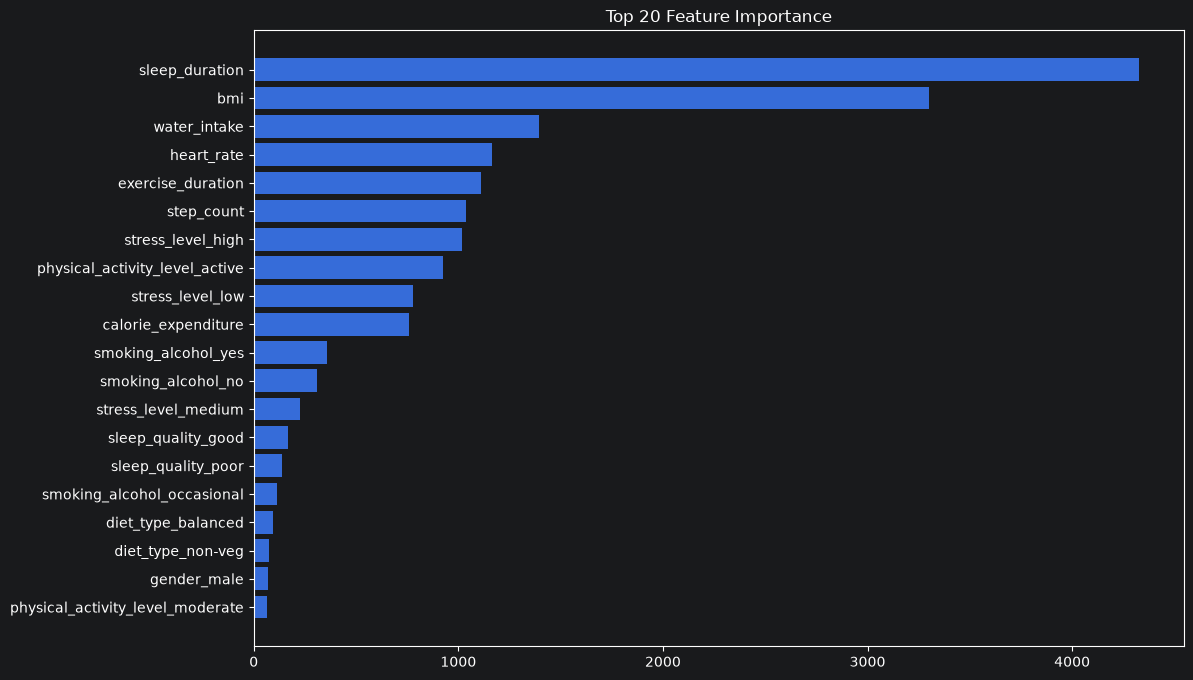

In [5]:
plt.figure(figsize=(12,8))

plt.barh(

    importance.head(20)["Feature"],

    importance.head(20)["Importance"]

)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importance")

plt.show()

In [6]:
explainer = shap.TreeExplainer(
    best_model
)

In [7]:
shap_values = explainer.shap_values(
    X_test_processed
)

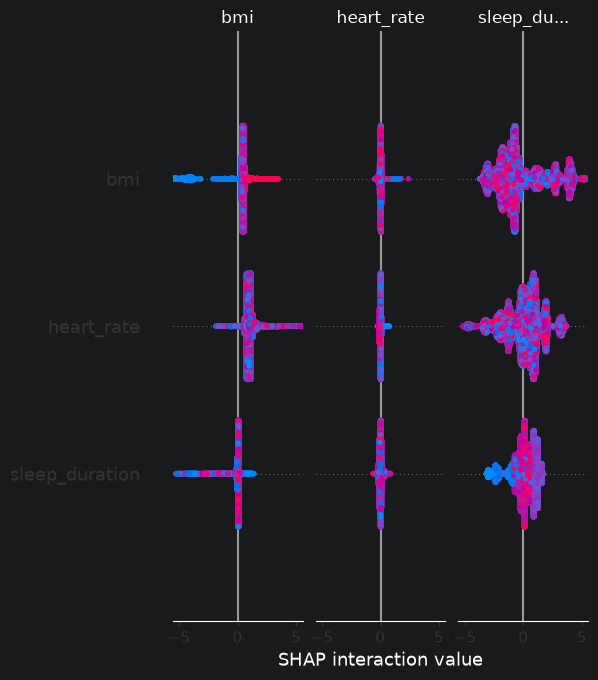

In [8]:
shap.summary_plot(
    shap_values,
    X_test_processed
)

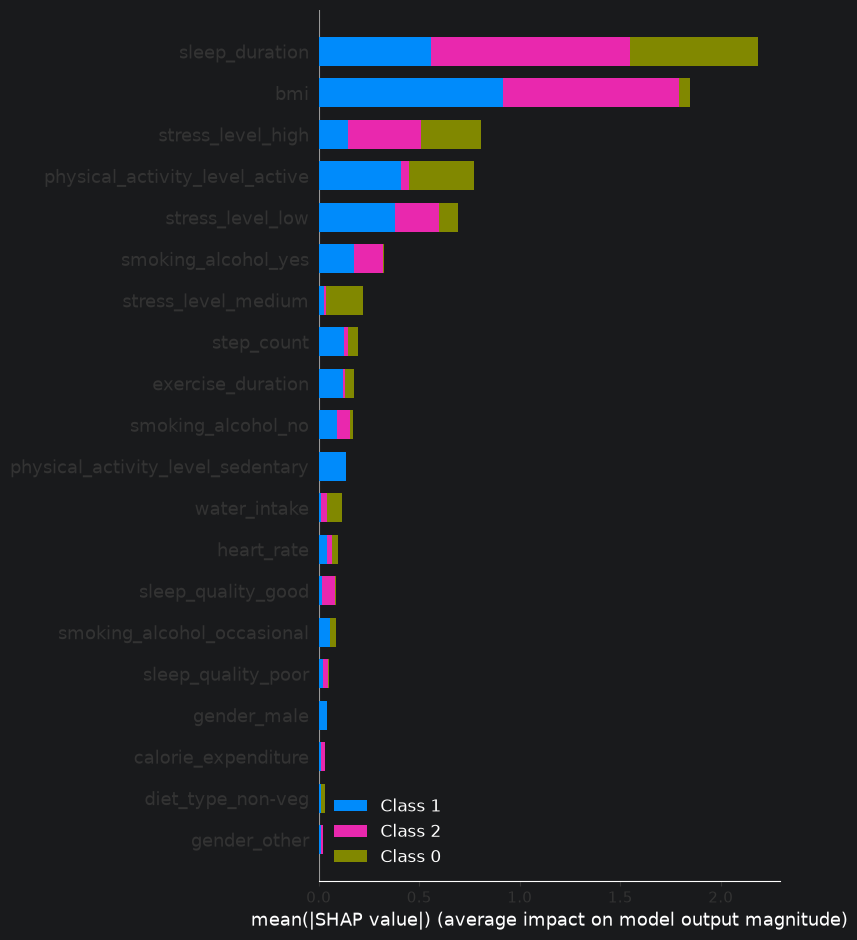

In [9]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    plot_type="bar"
)

In [10]:
sample = 10

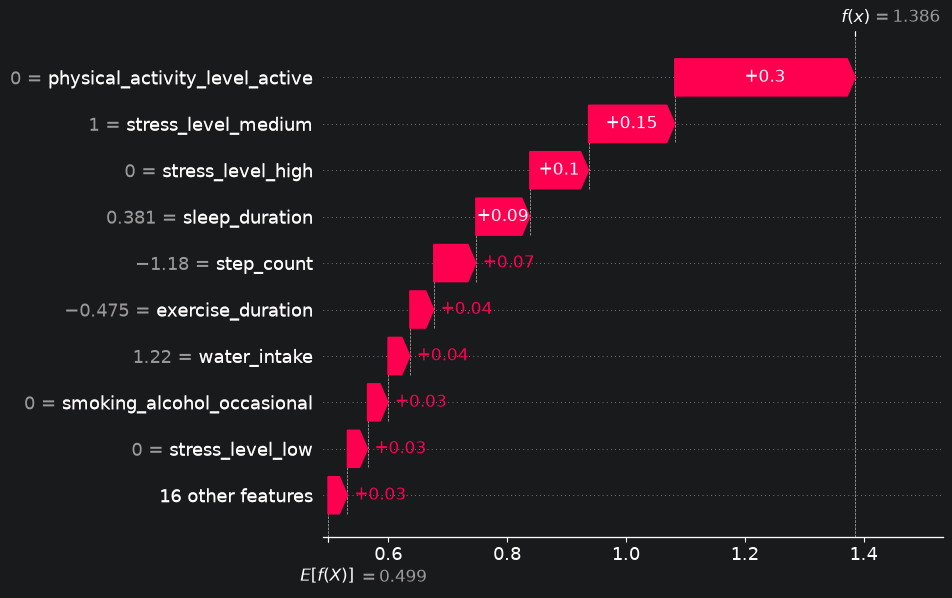

In [20]:
sample = 10

predicted_class = best_model.predict(
    X_test_processed.iloc[[sample]]
)[0]

explanation = shap.Explanation(
    values=shap_values[sample, :, predicted_class],
    base_values=explainer.expected_value[predicted_class],
    data=X_test_processed.iloc[sample].values,
    feature_names=X_test_processed.columns.tolist()
)

shap.plots.waterfall(explanation)

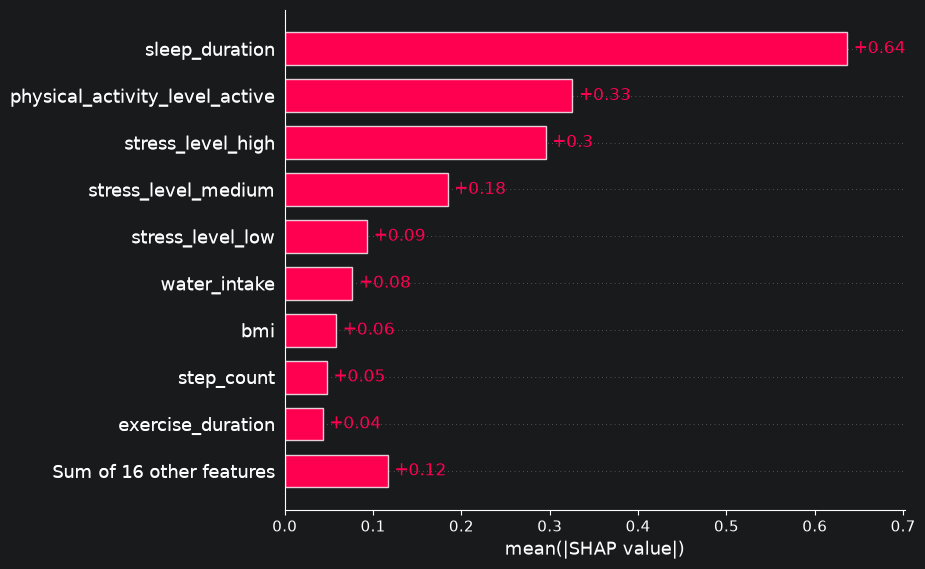

In [21]:
shap.plots.bar(
    shap.Explanation(
        values=shap_values[:, :, 0],
        feature_names=X_test_processed.columns
    )
)

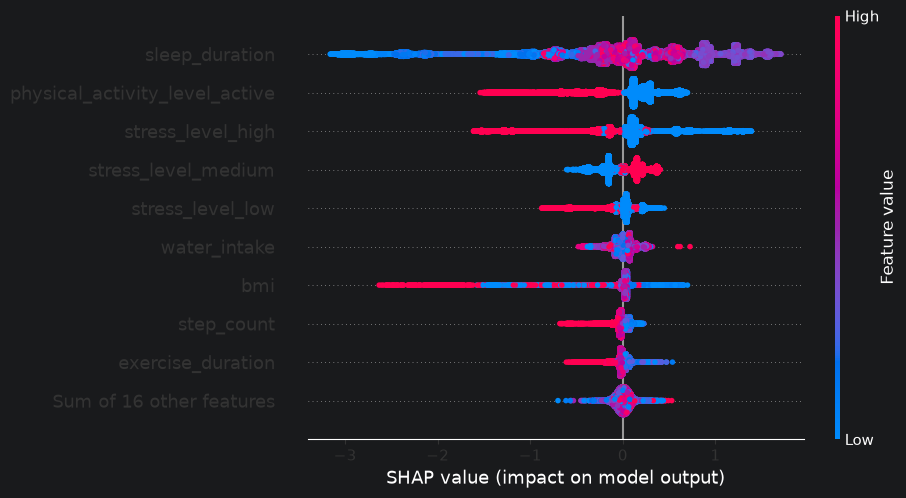

In [22]:
explanation = shap.Explanation(
    values=shap_values[:, :, 0],
    data=X_test_processed.values,
    feature_names=X_test_processed.columns
)

shap.plots.beeswarm(explanation)

SHAP Summary for Class: at-risk


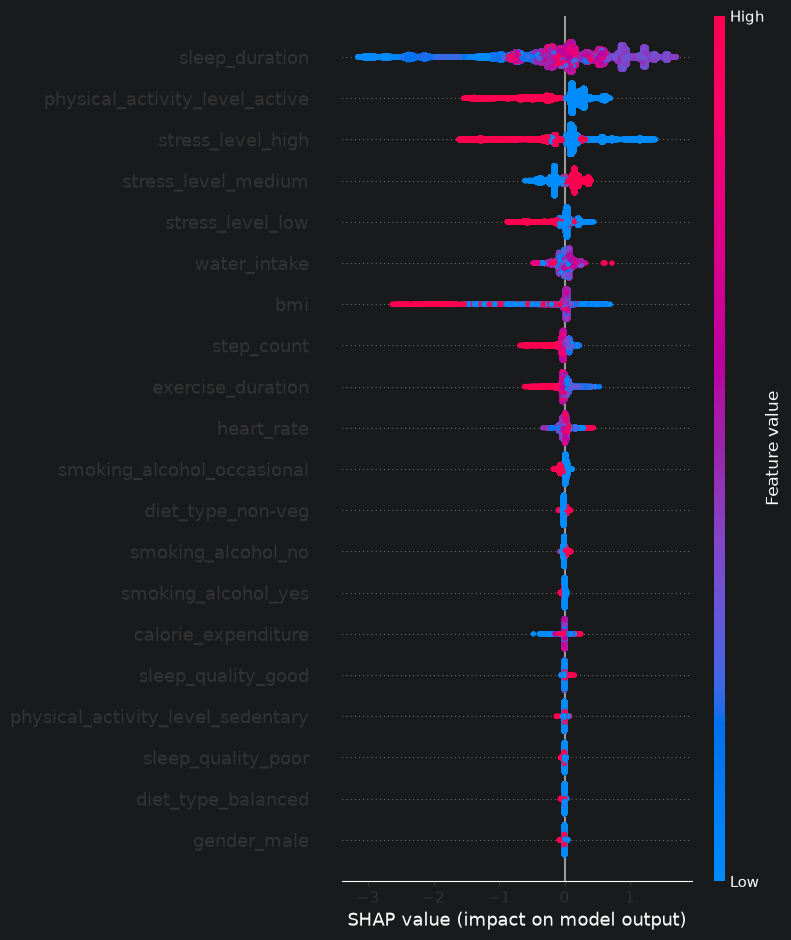

SHAP Summary for Class: fit


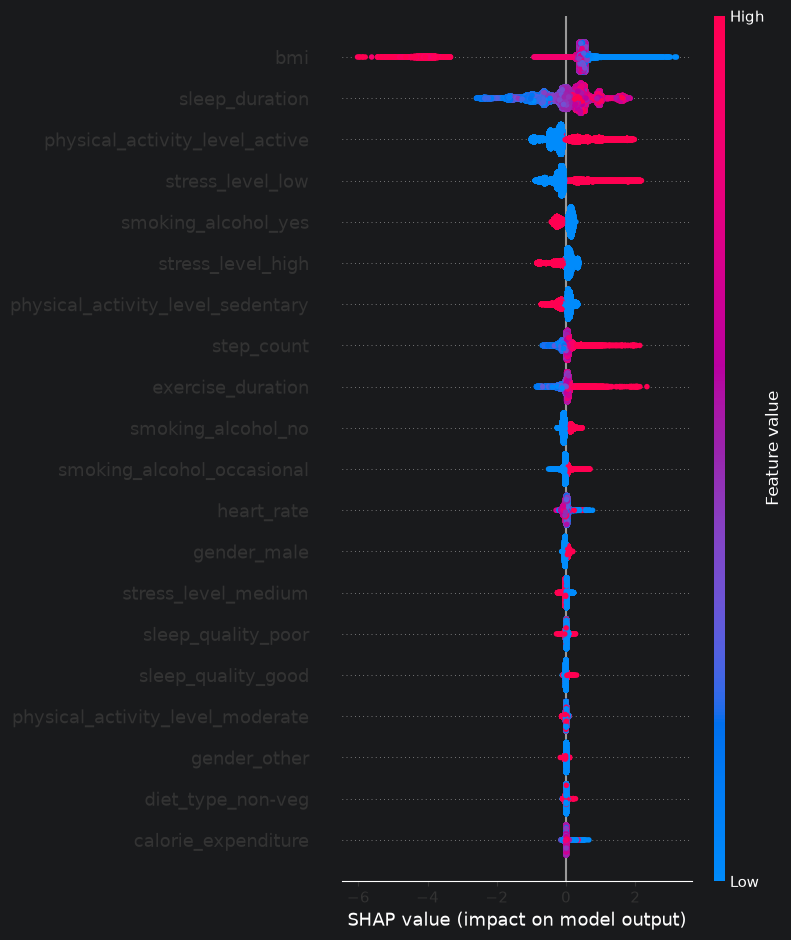

SHAP Summary for Class: unhealthy


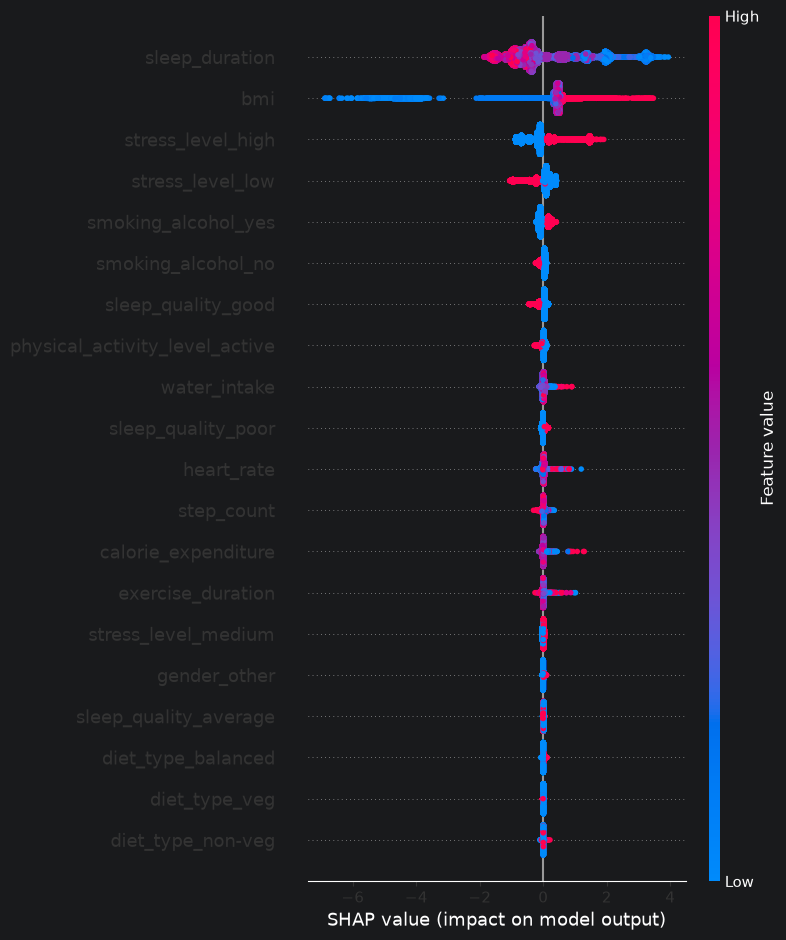

In [25]:
class_names = label_encoder.classes_

for i, class_name in enumerate(class_names):

    print("=" * 60)
    print(f"SHAP Summary for Class: {class_name}")

    shap.summary_plot(
        shap_values[:, :, i],
        X_test_processed,
        show=True
    )

In [18]:
shap.initjs()

sample = 10

predicted_class = best_model.predict(
    X_test_processed.iloc[[sample]]
)[0]

shap.force_plot(

    explainer.expected_value[predicted_class],

    shap_values[sample, :, predicted_class],

    X_test_processed.iloc[sample]

)

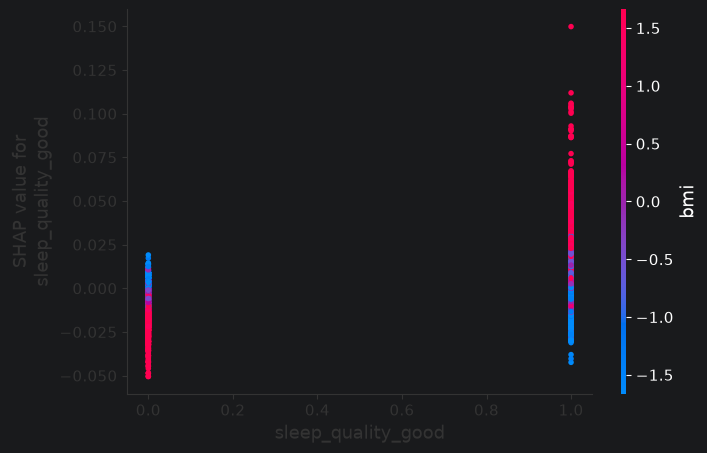

In [29]:
shap.dependence_plot(
    "sleep_quality_good",
    shap_values[:, :, 0],
    X_test_processed
)

In [30]:
sample = 25

predicted = best_model.predict(
    X_test_processed.iloc[[sample]]
)[0]

actual = y_test.iloc[sample]

print("Actual Class    :", actual)
print("Predicted Class :", label_encoder.inverse_transform([predicted])[0])

Actual Class    : at-risk
Predicted Class : at-risk


# Interpretation Summary

## Key Findings

- The SHAP analysis confirms that the model is making predictions based on meaningful health-related features.
- Stress level, sleep quality, BMI and physical activity are among the most influential variables.
- Individual prediction explanations demonstrate how each feature contributes positively or negatively toward a predicted class.
- These interpretability techniques improve transparency and increase confidence in deploying the model for decision support.

Overall, the selected LightGBM model provides both strong predictive performance and explainable outcomes.